In [1]:
import glob
import numpy as np
import os
import matplotlib.pyplot as plt

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-jyqjvum8 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:

# get black hole details from one 'BlackholeDetails'
def get_blackholedetails(file, fields_target=['BHID', 'BHMass', 'KineticFdbkEnergy', 'KEflag', 'z']): # get only BHID, KineticFdbkEnergy, KEflag, z (scale factor)
    fields = ('size','BHID','BHMass','Mdot','Density','timebin','Encounter','MinPos',\
        'MinPot','Entropy','GasVel','acMom','acMass','acBHMass',\
        'Fdbk','SPHID','SwallowID','CountProgs','Swallowed',\
        'BHpos','srDensity','srParticles','srVel','srDisp',\
        'DFAccel','DragAccel','GravAccel','BHvel','Mtrack','Mdyn',\
        'KineticFdbkEnergy','NumDM','V1sumDM','V2sumDM','MgasEnc','KEflag','z','size2')
    dtype = ('i','Q','d','d','d','i','i','3d',\
        'd','d','3d','3d','d','d',\
        'd','Q','Q','i','i',\
        '3d','d','d','3d','d',\
        '3d','3d','3d','3d','d','d',\
        'd','d','3d','d','d','i','d','i')
    dt = {'names':fields, 'formats':dtype}


    datadir = file
    bhfile_zoo = glob.glob(os.path.join(datadir,"*"))


    results = []
    for filename in bhfile_zoo:
        data = np.fromfile(filename, dtype=dt, count=-1)
        results.append(data[fields_target])
    results = np.concatenate(results)

    # filter all BHs at once
    # mask = np.isclose(results['z'], scale_factor, atol=1e-7, rtol=0)
    # filtered_bhs = results[mask]
    
    # create bhinfo array, fields: BHID, BHMass, Mdot, KEflag, z, dtype: Q, d, d, i, d
    bhinfo = results
    
    # ensure all 'z' values are the same exactly
    # unique_z = np.unique(bhinfo['z'])
    # if len(unique_z) > 1:
    #     raise ValueError(f"Multiple unique 'z' values found: {unique_z}")
    
    return bhinfo

# get black hole details from a list of 'BlackholeDetails' files
def get_bhinfo(file_list, fields_target=['BHID', 'BHMass', 'KineticFdbkEnergy', 'KEflag', 'z']):
    all_bhinfo = []
    for file in file_list:
        print(f"Reading BH details from {file}...")
        bhinfo = get_blackholedetails(file, fields_target)
        all_bhinfo.append(bhinfo)
    all_bhinfo = np.concatenate(all_bhinfo)
    return all_bhinfo

# find all BHs in kinetic feedback mode at a given scale factor, return their BHID
def find_kinetic_bhs(bhinfo, scale_factor=1.):
    # filter by scale factor
    mask = np.isclose(bhinfo['z'], scale_factor, atol=1e-7, rtol=0) & (bhinfo['KEflag'] != 0)
    ids = bhinfo['BHID'][mask]
    masses = bhinfo['BHMass'][mask]
    return ids, masses

# get activation time, the BH mass at activation and kinetic feedback energy released before a given scale factor for a given BHID
def get_bh_kinetic_info(bhinfo, bhid, scale_factor=1.):
    # filter by BHID and scale factor
    mask = (bhinfo['BHID'] == bhid) & (bhinfo['z'] <= scale_factor) & (bhinfo['KEflag'] != 0)

    # warn if no entries found
    if not np.any(mask):
        print(f"Warning: No entries found for BHID {bhid} at or before scale factor {scale_factor}.")
        return None, None, None
    # filtered_bhinfo = bhinfo[mask]
    # we need a copy for resorting later
    bhinfo_target = np.copy(bhinfo[mask])
    # sort by scale factor ascending
    sorted_indices = np.argsort(bhinfo_target['z'])
    bhinfo_target = bhinfo_target[sorted_indices]

    atime_activation = bhinfo_target['z'][0]
    mass_at_activation = bhinfo_target['BHMass'][0]
    # kinetic feedback energy released
    # find the indices where KEflag == 2 (release event)
    idx_release = np.where(bhinfo_target['KEflag'] == 2)[0]
    if len(idx_release) == 0:
        kenergy = 0.
    else:
        kenergy = np.sum(bhinfo_target['KineticFdbkEnergy'][idx_release-1])  # sum the energy released at each event (the energy is stored in the previous entry)

    return atime_activation, mass_at_activation, kenergy

# from a list of BlackholeDetails files, get BHID, BHMass, atime_activation, mass_at_activation, kenergy for all BHs in kinetic feedback mode at a given scale factor
# def get_kinetic_bhinfo(file_list, scale_factor=1.):
#     bhinfo = get_bhinfo(file_list, fields_target=['BHID', 'BHMass', 'KineticFdbkEnergy', 'KEflag', 'z'])

#     print(f"Finding BHs in kinetic feedback mode at scale factor {scale_factor}...")
#     kinetic_bhids, kinetic_bhmass = find_kinetic_bhs(bhinfo, scale_factor)
    
#     kinetic_bhinfo = {'BHID': [], 'BHMass': [], 'ActivationTime': [], 'ActivationMass': [], 'ReleasedKE': []}

#     print(f"Found {len(kinetic_bhids)} BHs in kinetic feedback mode at scale factor {scale_factor}.")
#     print("Processing each kinetic-mode BH to get details...")
#     for i, bhid in enumerate(kinetic_bhids):
#         atime_activation, mass_at_activation, kenergy = get_bh_kinetic_info(bhinfo, bhid, scale_factor)
#         if atime_activation is not None:
#             kinetic_bhinfo['BHID'].append(bhid)
#             kinetic_bhinfo['BHMass'].append(kinetic_bhmass[i])
#             kinetic_bhinfo['ActivationTime'].append(atime_activation)
#             kinetic_bhinfo['ActivationMass'].append(mass_at_activation)
#             kinetic_bhinfo['ReleasedKE'].append(kenergy)

#     # convert lists to numpy arrays
#     for key in kinetic_bhinfo:
#         kinetic_bhinfo[key] = np.array(kinetic_bhinfo[key])
#     return kinetic_bhinfo

def get_kinetic_bhinfo(file_list, scale_factor=1.):
    bhinfo = get_bhinfo(file_list, fields_target=['BHID', 'BHMass', 'KineticFdbkEnergy', 'KEflag', 'z'])

    # Filter once
    mask = (bhinfo['KEflag'] != 0) & (bhinfo['z'] <= scale_factor)
    data = bhinfo[mask]

    # Sort by BHID, then z
    order = np.lexsort((data['z'], data['BHID']))
    data = data[order]

    bhid = data['BHID']
    z = data['z']
    ke = data['KineticFdbkEnergy']
    keflag = data['KEflag']
    mass = data['BHMass']

    # Find BHID boundaries
    unique_bhids, start_idx = np.unique(bhid, return_index=True)

    out = {
        'BHID': [],
        'BHMass': [],
        'ActivationTime': [],
        'ActivationMass': [],
        'ReleasedKE': []
    }

    for i, start in enumerate(start_idx):
        end = start_idx[i + 1] if i + 1 < len(start_idx) else len(bhid)

        z_bh = z[start:end]
        ke_bh = ke[start:end]
        keflag_bh = keflag[start:end]
        mass_bh = mass[start:end]

        # activation
        out['BHID'].append(unique_bhids[i])
        out['ActivationTime'].append(z_bh[0])
        out['ActivationMass'].append(mass_bh[0])
        out['BHMass'].append(mass_bh[-1])

        # released KE (flag==2 → energy in previous entry)
        idx = np.where(keflag_bh == 2)[0]
        if len(idx):
            out['ReleasedKE'].append(np.sum(ke_bh[idx - 1]))
        else:
            out['ReleasedKE'].append(0.0)

    for k in out:
        out[k] = np.asarray(out[k])

    return out


# def get_kinetic_bhinfo_fast(bhinfo, scale_factor=1.0):
    # Filter once
    mask = (bhinfo['KEflag'] != 0) & (bhinfo['z'] <= scale_factor)
    data = bhinfo[mask]

    # Sort by BHID, then z
    order = np.lexsort((data['z'], data['BHID']))
    data = data[order]

    bhid = data['BHID']
    z = data['z']
    ke = data['KineticFdbkEnergy']
    keflag = data['KEflag']
    mass = data['BHMass']

    # Find BHID boundaries
    unique_bhids, start_idx = np.unique(bhid, return_index=True)

    out = {
        'BHID': [],
        'BHMass': [],
        'ActivationTime': [],
        'ActivationMass': [],
        'ReleasedKE': []
    }

    for i, start in enumerate(start_idx):
        end = start_idx[i + 1] if i + 1 < len(start_idx) else len(bhid)

        z_bh = z[start:end]
        ke_bh = ke[start:end]
        keflag_bh = keflag[start:end]
        mass_bh = mass[start:end]

        # activation
        out['BHID'].append(unique_bhids[i])
        out['ActivationTime'].append(z_bh[0])
        out['ActivationMass'].append(mass_bh[0])
        out['BHMass'].append(mass_bh[-1])

        # released KE (flag==2 → energy in previous entry)
        idx = np.where(keflag_bh == 2)[0]
        if len(idx):
            out['ReleasedKE'].append(np.sum(ke_bh[idx - 1]))
        else:
            out['ReleasedKE'].append(0.0)

    for k in out:
        out[k] = np.asarray(out[k])

    return out

In [4]:
# load kinetic BH info at scale factor 1.0 (redshift 0)
BD_files = glob.glob('/scratch3/01317/yyang440/small_Astrid/kn1-DF/output/BlackholeDetails*')  # replace with actual path
kBHinfo = get_kinetic_bhinfo(BD_files)

Reading BH details from /scratch3/01317/yyang440/small_Astrid/kn1-DF/output/BlackholeDetails-R002.0...
Reading BH details from /scratch3/01317/yyang440/small_Astrid/kn1-DF/output/BlackholeDetails-R002...
Reading BH details from /scratch3/01317/yyang440/small_Astrid/kn1-DF/output/BlackholeDetails-R016...
Reading BH details from /scratch3/01317/yyang440/small_Astrid/kn1-DF/output/BlackholeDetails...
Reading BH details from /scratch3/01317/yyang440/small_Astrid/kn1-DF/output/BlackholeDetails-R002.2...
Reading BH details from /scratch3/01317/yyang440/small_Astrid/kn1-DF/output/BlackholeDetails-R002.1...


In [7]:
# unit conversion
f_mass = 1e10  # 1e10 Msun/h to Msun/h
f_energy = 1e10 * (1e5)**2 * 1.989e33  # 1e10 Msun/h *(km/s)^2 to erg/h
kBHinfo['ActivationMass'] *= f_mass  # to Msun/h
kBHinfo['BHMass'] *= f_mass  # to Msun/h
kBHinfo['ReleasedKE'] *= f_energy  # to erg/h

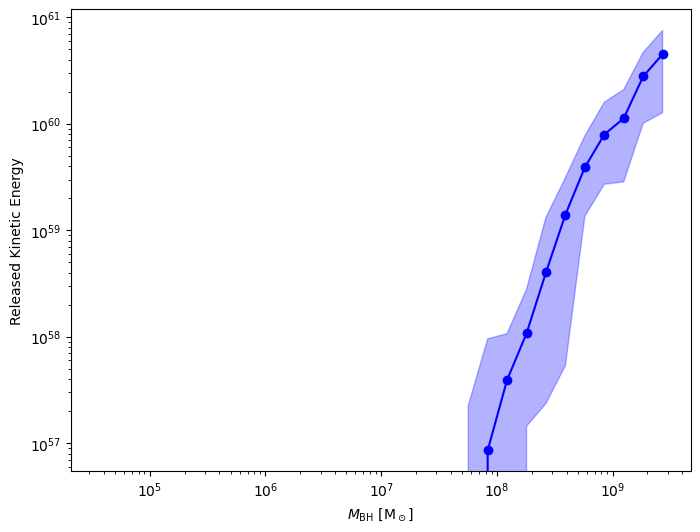

In [ ]:
def plot_with_percentiles(ax, x, y, xbins=30):
    # define bins in logarithmic space
    x_edges = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), xbins+1)
    x_centers = np.sqrt(x_edges[:-1] * x_edges[1:])

    y_median = []
    y_p16 = []  # 16th percentile in log space
    y_p84 = []

    for i in range(xbins):
        mask = (x >= x_edges[i]) & (x < x_edges[i+1])
        if np.sum(mask) > 0:
            y_bin = y[mask]
            y_median.append(np.median(y_bin))
            y_p16.append(np.percentile(y_bin, 16))
            y_p84.append(np.percentile(y_bin, 84))
        else:
            y_median.append(np.nan)
            y_p16.append(np.nan)
            y_p84.append(np.nan)

    y_median = np.array(y_median)
    y_p16 = np.array(y_p16)
    y_p84 = np.array(y_p84)
    ax.plot(x_centers, y_median, marker='o', linestyle='-', color='blue', label='Median')
    ax.fill_between(x_centers, y_p16, y_p84, color='blue', alpha=0.3, label='16th-84th Percentile')
    



# plot kenergy vs BHMass median and 16th, 84th percentiles

# make a figure
fig, ax = plt.subplots(figsize=(8,6))

plot_with_percentiles(ax, kBHinfo['BHMass'], kBHinfo['ReleasedKE'], xbins=30)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_\mathrm{BH}$ [M$_\odot/h$]')
ax.set_ylabel('Released Kinetic Energy [erg$/h$]')

plt.show()